In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
print(os.listdir('dados/eletro'))

['data.csv']


In [3]:
df = pd.read_csv('dados/eletro/data.csv')

In [4]:
df.head()

,CondensedBinary2DGeometry,BandGapLocation,BandGapWidth
0,10.0,497.011658,22.697266
1,11.0,467.929018,85.654936
2,100.0,687.636705,37.409815
3,101.0,721.282777,61.604756
4,110.0,464.347767,46.354707


In [5]:
# Vou ver qual das duas tem mais correlação para usar como atributo -> O exercício é sobre regressão linear, sem usar bibliotecas, e a pura mesmo ( 1 atributo )

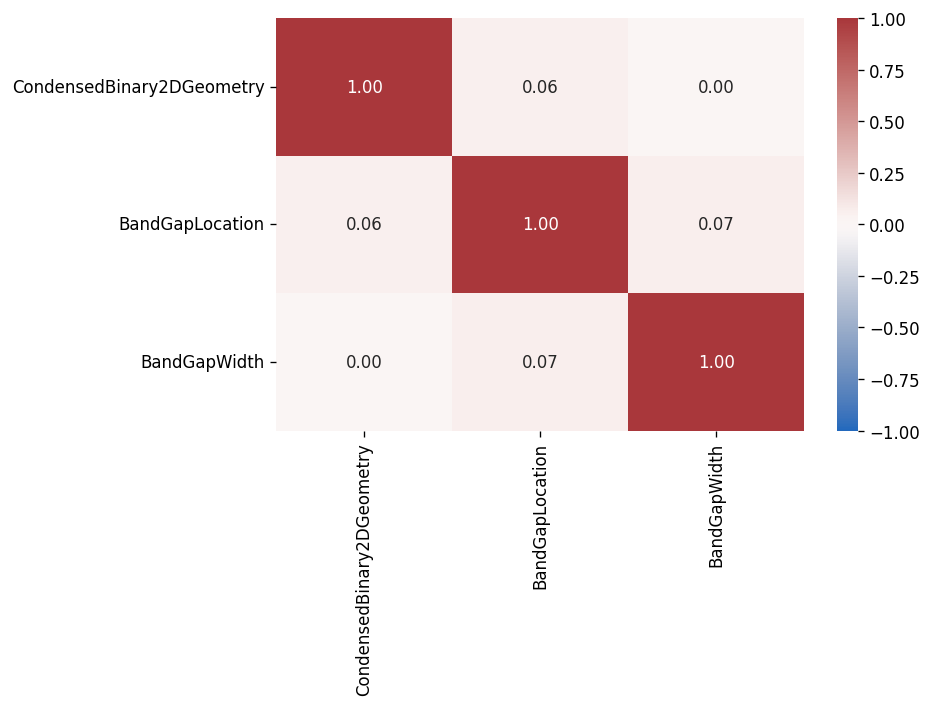

In [6]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(8,6), dpi=120)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
fig.tight_layout()
plt.show()

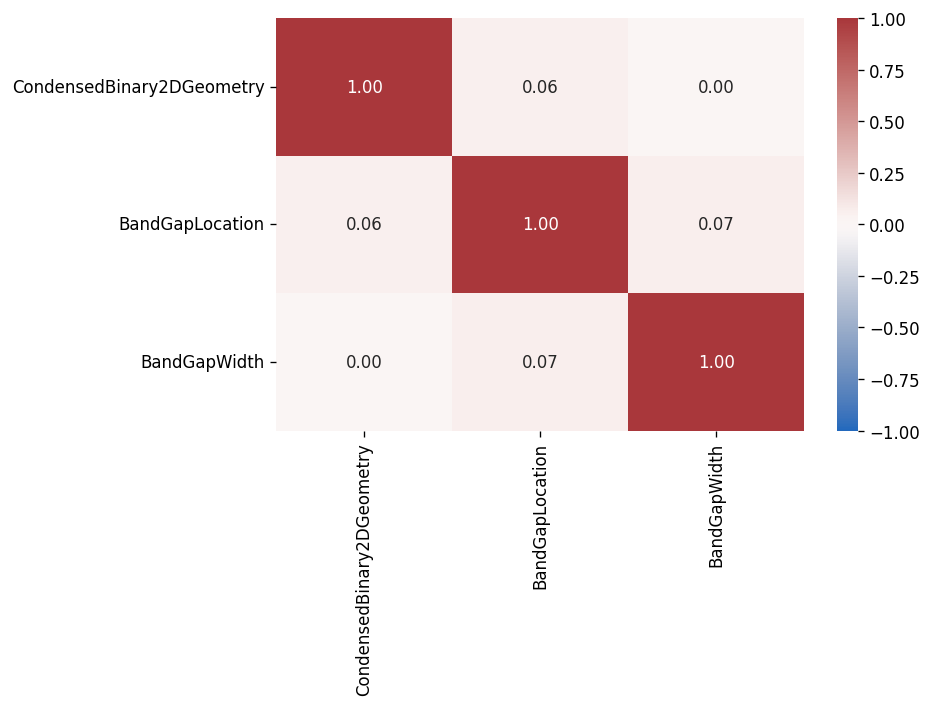

In [7]:
# Aparentemente é aquela, mas é porque não esta normalizado será?

df_n = df.copy()

# Normalização z-score
for column in df_n.columns: 
    df_n[column] = (df_n[column] - df_n[column].mean()) / df_n[column].std()


corr_n = df_n.corr()
fig, ax = plt.subplots(figsize=(8,6), dpi=120)
sns.heatmap(corr_n , annot=True, fmt=".2f", cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
fig.tight_layout()
plt.show()

# Mesma coisa, vou relacionar BandGapLocation com o condesedbinary2dgeomtry

In [8]:
df.head()

,CondensedBinary2DGeometry,BandGapLocation,BandGapWidth
0,10.0,497.011658,22.697266
1,11.0,467.929018,85.654936
2,100.0,687.636705,37.409815
3,101.0,721.282777,61.604756
4,110.0,464.347767,46.354707


In [41]:
# Como não tem diferença vou manter o original
X = df['BandGapLocation'].to_numpy()
Y = df['CondensedBinary2DGeometry'].to_numpy()

train_pct_index = int(0.8 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = Y[:train_pct_index], Y[train_pct_index:]

print(len(X_train)) # 80% -> não sei como shufflar sem uma biblioteca e não queria usar uma também
print(len(X_test))

16416
4104


# Beleza, tenho os vetor de treinamento, mas como eu modelo?

ho(x) = theta0 + theta1*x1 <- como eu passo isso?


In [ ]:
class LMSTrainer:

    def __init__(self, a, iter, limiar):

        self.w0, self.w1 = 0,0 # pesos
        self.a = a # taxa de aprendizagem
        self.iter = iter # quantidade de iterações = epochs
        self.limiar = limiar

    def train(self, x, y):
        

        for i in range(self.iter) :

            # predição do modelo
            y_pred = self.w0 + self.w1 * x

            erro = (1/len(x)) * (np.sum((y_pred - y)**2))

            print("erro -> ", erro)
            #print((1/len(x))," * " ,))
            # aplicação do gradiente d  escendente

            #                   a        1/m       E(h0(x) - y)                                       
            w0_t = self.a * (1/len(x)) * np.sum((y_pred - y))
            w1_t = self.a * (1/len(x)) * np.sum((y_pred - y) * x)

            self.w0 = w0_t
            self.w1 = w1_t

            #print("x:", x)
            #print("y:", y)
            #print("a:", self.a)

            #print("gradiente w0:", dw0)
            #print("gradiente w1:", dw1)
        return self.w0, self.w1

In [ ]:
modelo_regressao_linear = LMSTrainer(
    a=0.000001,
    iter=10000,
    limiar=0.001
)

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
vetores_peso = modelo_regressao_linear.train(X_train, y_train)
print(vetores_peso)

erro ->  4.121003647754648e+27
erro ->  1.1171489192828257e+28
erro ->  3.042537317980964e+28
erro ->  7.52355853006531e+28
erro ->  1.7199513234702715e+29
erro ->  3.7236937473042894e+29
erro ->  7.768228510799813e+29
erro ->  1.5798022258634415e+30
erro ->  3.156417163381371e+30
erro ->  6.228605305363962e+30
erro ->  1.2183490650565855e+31
erro ->  2.368308958647666e+31
erro ->  4.583165846686592e+31
erro ->  8.841024322209221e+31
erro ->  1.70153439625551e+32
erro ->  3.2693390778546276e+32
erro ->  6.2742400564478636e+32
erro ->  1.2030637163129687e+33
erro ->  2.3054007764157297e+33
erro ->  4.4158010823761944e+33
erro ->  8.455356085781897e+33
erro ->  1.618648951425594e+34
erro ->  3.0981325553464773e+34
erro ->  5.929174620364304e+34
erro ->  1.1346191802889489e+35
erro ->  2.1710922061330753e+35
erro ->  4.15419011956108e+35
erro ->  7.948404788326334e+35
erro ->  1.5207684964894477e+36
erro ->  2.909636018328318e+36
erro ->  5.566840080013357e+36
erro ->  1.0650619460802372e

c:\Users\RAFAEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\RAFAEL\AppData\Local\Temp\ipykernel_19452\3435118787.py:18: RuntimeWarning: overflow encountered in square
  erro = (1/len(x)) * (np.sum((y_pred - y)**2))


erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf
erro ->  inf

In [44]:
class LMSPredictor:
    def __init__(self, w0, w1):
        self.w0 = w0
        self.w1 = w1

    def predict(self, x):
        a = self.w0 + self.w1*x
        print("w0 = ", self.w0)
        print("w1 = ", self.w1)
        print("x = ", x)
        return a

In [45]:
preditor = LMSPredictor(vetores_peso[0], vetores_peso[1])

In [40]:
print(f"Entrada: " ,X_test[0], ", saída -> ", y_test[0])
a = X_test[0]
print(f"Entrada: " ,X_test[0], ", saída -> ", preditor.predict(a))

Entrada:  0.852362898932907 , saída ->  1.0594404992868611
w0 =  -0.002670825790357085
w1 =  -0.000272279464940093
x =  0.852362898932907
Entrada:  0.852362898932907 , saída ->  -0.0029029067044133235
